In [44]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [45]:
df=pd.read_csv('regression_dataset.csv')
df.head()

,feature_1_size,feature_2_age,feature_3_score,feature_4_size_related,feature_5_score_related,feature_6_noise,feature_7_noise,feature_8_noise,feature_9_noise,feature_10_noise,target
0,54.967,15.855,0.757,44.711,0.719,0.778,8.802,-0.727,106.867,0.084,271.250
1,48.617,17.199,-0.922,38.107,-0.959,-0.551,4.879,0.303,125.117,1.410,220.980
2,56.477,23.736,0.870,45.239,0.819,-0.818,3.583,0.477,99.916,0.410,264.984
3,65.230,23.052,1.356,54.741,1.383,-0.003,1.973,-0.369,110.031,-0.861,314.712
4,47.658,19.895,0.413,38.509,0.387,-0.170,1.394,0.290,83.624,1.403,226.949


In [46]:
df.corr()

,feature_1_size,feature_2_age,feature_3_score,feature_4_size_related,feature_5_score_related,feature_6_noise,feature_7_noise,feature_8_noise,feature_9_noise,feature_10_noise,target
feature_1_size,1.000000,-0.040508,-0.037814,0.969797,-0.021440,0.114223,-0.033969,0.013142,-0.081508,-0.034268,0.928200
feature_2_age,-0.040508,1.000000,-0.031314,-0.050503,-0.064753,-0.001820,0.001317,0.059580,0.011017,-0.040197,-0.249878
feature_3_score,-0.037814,-0.031314,1.000000,-0.038285,0.950210,-0.006490,0.009658,0.025487,-0.035016,-0.011140,0.217515
feature_4_size_related,0.969797,-0.050503,-0.038285,1.000000,-0.024589,0.131265,-0.036995,-0.005942,-0.059641,-0.003714,0.917888
feature_5_score_related,-0.021440,-0.064753,0.950210,-0.024589,1.000000,-0.026418,0.006955,0.000285,-0.053231,0.016102,0.215034
feature_6_noise,0.114223,-0.001820,-0.006490,0.131265,-0.026418,1.000000,-0.017036,-0.042653,0.069494,0.012453,0.113166
feature_7_noise,-0.033969,0.001317,0.009658,-0.036995,0.006955,-0.017036,1.000000,-0.059643,0.047667,0.113426,-0.024645
feature_8_noise,0.013142,0.059580,0.025487,-0.005942,0.000285,-0.042653,-0.059643,1.000000,0.080601,-0.079734,0.008142
feature_9_noise,-0.081508,0.011017,-0.035016,-0.059641,-0.053231,0.069494,0.047667,0.080601,1.000000,0.027191,-0.073556
feature_10_noise,-0.034268,-0.040197,-0.011140,-0.003714,0.016102,0.012453,0.113426,-0.079734,0.027191,1.000000,-0.017756


<Axes: ylabel='target'>

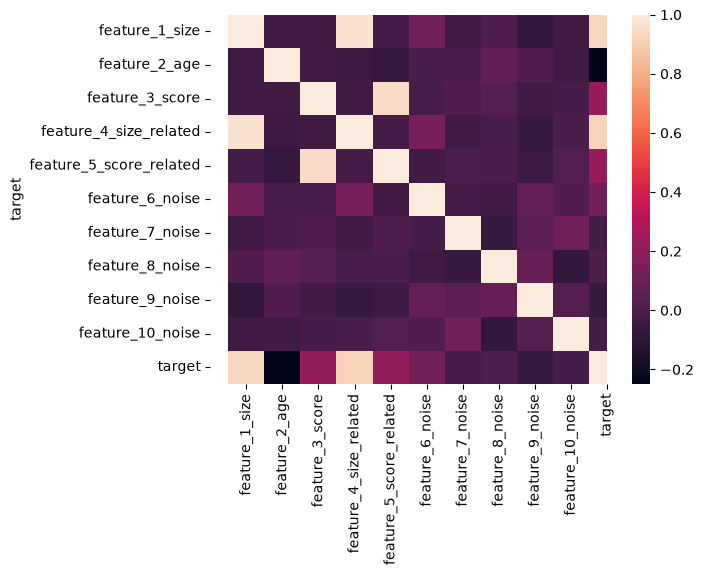

In [47]:
sns.heatmap(df.corr())
sns.boxplot(df['target'])

In [48]:
x=df.drop('target', axis=1)
y=df['target']

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.25, random_state=42)

In [50]:
x_train.shape

(225, 10)

In [51]:
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr            

In [52]:
core_feature=correlation(x_train, 0.80)

In [53]:
x_train.drop(core_feature, axis=1, inplace=True)
x_test.drop(core_feature, axis=1, inplace=True)

In [54]:
print(x_train.shape, x_test.shape)

(225, 8) (75, 8)


In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

<Axes: >

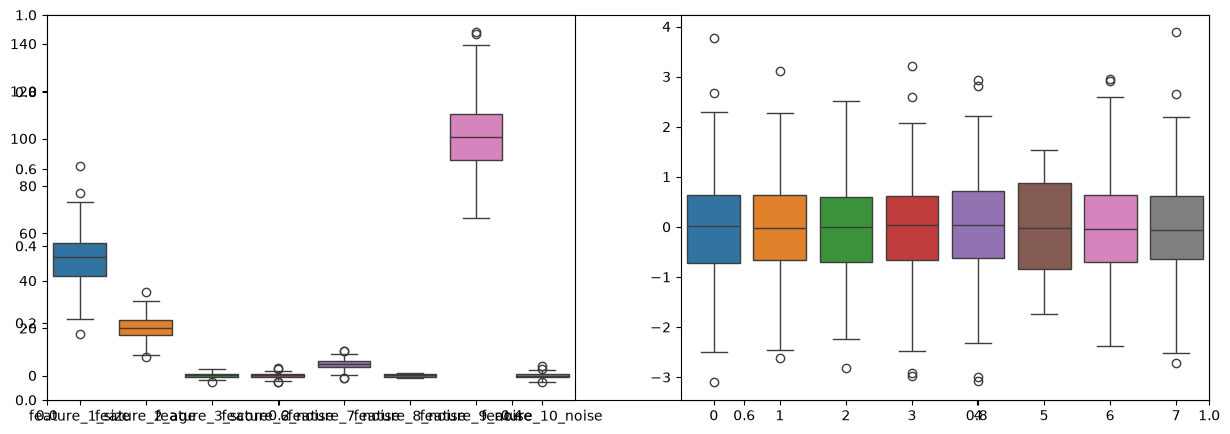

In [56]:
plt.subplots(figsize=(15, 5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_scaled, y_train)
y_pred=regression.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.051110335716994
0.9534596741221959


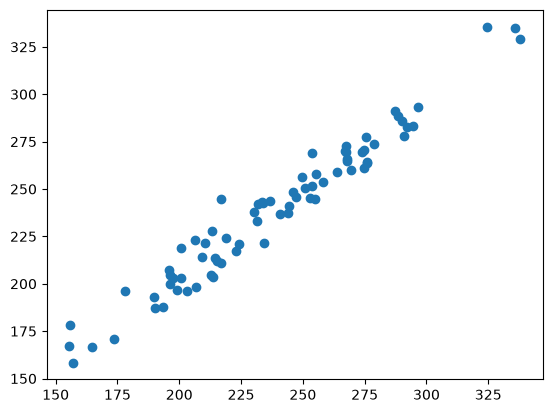

In [58]:
plt.scatter(y_test, y_pred)

In [59]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.126010774327427
0.9518432045959382


In [60]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.08183049759619
0.9530963234465171


In [61]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnet=ElasticNet()
elasticnet.fit(x_train_scaled, y_train)
y_pred=elasticnet.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

14.119381194955793
0.8241665952861194


In [62]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled, y_train)
y_pred=lassocv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.048457589848565
0.9530275810397212


In [63]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled, y_train)
y_pred=ridgecv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.08183049759619
0.9530963234465171


In [64]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(x_train_scaled, y_train)
y_pred=elasticnetcv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

7.4341744567044525
0.9481060767113535


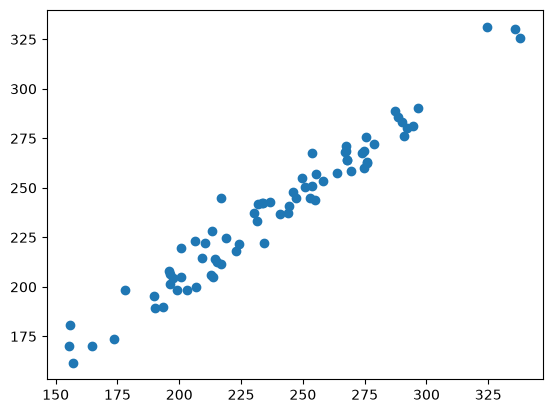

In [65]:
plt.scatter(y_test, y_pred)

In [68]:
print( y_test - y_pred)

203     6.124121
266    12.344355
152    -5.488790
9       0.216930
233   -12.170461
         ...    
108   -18.565799
126     5.086489
230   -24.699555
193    -0.044550
129   -11.881974
Name: target, Length: 75, dtype: float64


In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()